# Simulating the temperature-invariant noise floor for softmax under a shortfall DGP

This notebook builds synthetic experiments around the endpoint-shortfall model used in the draft:

\[
b - X_s = q(s)\,W, \qquad W \ge 0,
\]

which implies large-\(K\) top-1 probabilities of the form

\[
p_i^\star \propto q(s_i)^{-\beta}.
\]

The goal is to make the **statistical** point precise:

* even if the data are generated from a shortfall model,
* and even if we fit them with a softmax estimator,
* tuning the temperature \(\tau\) does **not** remove the \(O(1/n)\) sampling floor of any **identifiable** softmax quantity.

We also add the complementary comparison that matters for the paper:

* if we replace the misspecified translation-coordinate softmax by the correctly specified **Weibit** link, the nonvanishing **misspecification floor** for the true shortfall log-odds disappears.

## What this notebook shows

We separate four cases:

1. **Binary closed form.**  
   A softmax estimator of the utility gap has
   \[
   \hat \theta = \hat d_\tau / \tau = \operatorname{logit}(\hat p),
   \]
   so
   \[
   n\,\mathrm{Var}(\hat\theta) \to \frac{1}{p^\star(1-p^\star)},
   \]
   independent of \(\tau\).

2. **Multiclass unrestricted logits.**  
   If we estimate a full softmax utility vector with a fixed temperature,
   the identifiable object is the reference-logit vector
   \[
   \theta_i = (u_i-u_0)/\tau = \log(p_i/p_0).
   \]
   Its asymptotic covariance is a multinomial delta-method object and does not depend on \(\tau\).

3. **Misspecified one-parameter softmax.**  
   We fit
   \[
   q_i(\theta)=\mathrm{softmax}(\theta s_i)
   \]
   to shortfall probabilities \(p^\star\propto (1-s_i)^{-\beta}\).  
   The estimator converges to a pseudo-true coefficient \(\theta^\circ\) and still has a temperature-invariant sandwich variance floor.

4. **Correctly specified Weibit.**  
   Writing \(x_i=-\log(1-s_i)\), the same shortfall law becomes
   \[
   p_i^\star = \mathrm{softmax}(\beta x_i).
   \]
   Estimating the **Weibit** link removes the misspecification floor for the true log-odds: its MSE decays like \(1/n\), while the misspecified softmax MSE plateaus at a positive bias floor.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

rng = np.random.default_rng(20260113)


def softmax(z, axis=-1):
    z = np.asarray(z, dtype=float)
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)


def shortfall_probs(scores, beta=1.0, endpoint=1.0, q=None):
    scores = np.asarray(scores, dtype=float)
    if q is None:
        q = endpoint - scores
    q = np.asarray(q, dtype=float)
    if np.any(q <= 0):
        raise ValueError("Shortfalls q(s) must be strictly positive.")
    w = q ** (-beta)
    return w / w.sum()


def logit(p):
    p = np.asarray(p, dtype=float)
    return np.log(p / (1 - p))


def smoothed_freq(counts, alpha=0.5):
    """Haldane-Anscombe style smoothing to keep logs finite in finite samples."""
    counts = np.asarray(counts, dtype=float)
    n = counts.sum(axis=-1, keepdims=True)
    k = counts.shape[-1]
    return (counts + alpha) / (n + k * alpha)


def multinomial_logit_cov(p, ref=0):
    """
    Asymptotic covariance of reference-category logits
    theta_j = log(p_j / p_ref), j != ref.
    """
    p = np.asarray(p, dtype=float)
    k = len(p)
    idx = [j for j in range(k) if j != ref]
    J = np.zeros((k - 1, k))
    for r, j in enumerate(idx):
        J[r, j] = 1.0 / p[j]
        J[r, ref] = -1.0 / p[ref]
    Sigma_p = np.diag(p) - np.outer(p, p)
    return J @ Sigma_p @ J.T


def softmax_probs_from_theta(theta, scores):
    theta = np.asarray(theta, dtype=float)
    scores = np.asarray(scores, dtype=float)
    if theta.ndim == 0:
        return softmax(theta * scores)
    z = np.outer(theta, scores)
    return softmax(z, axis=1)


def invert_softmax_mean(targets, scores, lo=-80.0, hi=80.0, n_iter=80):
    """
    Solve E_q[s] = target for q_i(theta) = softmax(theta * s_i).
    Uses vectorized bisection; the map theta -> E_q[s] is monotone.
    """
    targets = np.asarray(targets, dtype=float)
    scores = np.asarray(scores, dtype=float)
    smin, smax = np.min(scores), np.max(scores)
    eps = 1e-12
    targets = np.clip(targets, smin + eps, smax - eps)

    lo_arr = np.full_like(targets, lo, dtype=float)
    hi_arr = np.full_like(targets, hi, dtype=float)

    for _ in range(n_iter):
        mid = (lo_arr + hi_arr) / 2.0
        q = softmax_probs_from_theta(mid, scores)
        mu = (q * scores).sum(axis=1)
        mask = mu < targets
        lo_arr[mask] = mid[mask]
        hi_arr[~mask] = mid[~mask]

    return (lo_arr + hi_arr) / 2.0


def summarize_grouped(df, value_col, by=("n", "tau"), sort=True):
    out = (
        df.groupby(list(by), as_index=False)[value_col]
        .mean()
        .rename(columns={value_col: f"mean_{value_col}"})
    )
    if sort:
        out = out.sort_values(list(by)).reset_index(drop=True)
    return out


Matplotlib is building the font cache; this may take a moment.



## 1. Binary closed form

We first isolate the pure sampling floor in the cleanest possible setting.

### Data-generating process

Take two candidates with bounded scores \(s_0 < s_1 < 1\), define shortfalls \(q(s)=1-s\), and generate the winner using

\[
p^\star = \Pr(Y=1) = \frac{(1-s_1)^{-\beta}}{(1-s_0)^{-\beta} + (1-s_1)^{-\beta}}.
\]

### Softmax estimator

If we fit a binary softmax with a fixed temperature \(\tau\), the utility gap is \(d_\tau\) and the identifiable normalized index is

\[
\theta = d_\tau/\tau.
\]

The MLE is

\[
\hat\theta = \operatorname{logit}(\hat p), \qquad \hat d_\tau = \tau \hat\theta,
\]

so the delta method gives

\[
n\,\mathrm{Var}(\hat\theta) \to \frac{1}{p^\star(1-p^\star)}.
\]

That floor is independent of \(\tau\), whereas

\[
n\,\mathrm{Var}(\hat d_\tau) \to \tau^2 \frac{1}{p^\star(1-p^\star)}
\]

just reflects a change of units.


In [2]:

# Binary setup
scores_binary = np.array([0.25, 0.75])
beta_binary = 1.0
p1_star = shortfall_probs(scores_binary, beta=beta_binary)[1]
binary_floor = 1.0 / (p1_star * (1.0 - p1_star))

tau_grid = [0.25, 0.5, 1.0, 2.0]
n_grid = [200, 500, 1000, 5000]
R_binary = 20_000

print(f"Shortfall scores: {scores_binary}")
print(f"beta = {beta_binary}")
print(f"True Bernoulli probability p* = {p1_star:.4f}")
print(f"Theoretical floor for n Var(theta_hat): {binary_floor:.4f}")


Shortfall scores: [0.25 0.75]
beta = 1.0
True Bernoulli probability p* = 0.7500
Theoretical floor for n Var(theta_hat): 5.3333


In [3]:

binary_rows = []

for n in n_grid:
    counts_1 = rng.binomial(n, p1_star, size=R_binary)
    p_hat = np.clip(counts_1 / n, 1 / (2 * n), 1 - 1 / (2 * n))
    theta_hat = logit(p_hat)

    for tau in tau_grid:
        d_hat_tau = tau * theta_hat
        binary_rows.append(
            {
                "n": n,
                "tau": tau,
                "nVar_theta_hat": n * np.var(theta_hat, ddof=1),
                "nVar_d_hat_tau": n * np.var(d_hat_tau, ddof=1),
            }
        )

binary_df = pd.DataFrame(binary_rows)
binary_df


,n,tau,nVar_theta_hat,nVar_d_hat_tau
0,200,0.2500,5.4010,0.3376
1,200,0.5000,5.4010,1.3503
2,200,1.0000,5.4010,5.4010
3,200,2.0000,5.4010,21.6041
4,500,0.2500,5.4016,0.3376
5,500,0.5000,5.4016,1.3504
6,500,1.0000,5.4016,5.4016
7,500,2.0000,5.4016,21.6062
8,1000,0.2500,5.2531,0.3283
9,1000,0.5000,5.2531,1.3133


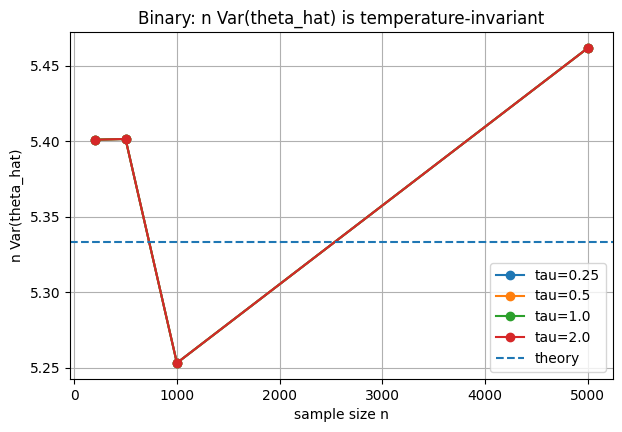

In [4]:

fig, ax = plt.subplots()
for tau in tau_grid:
    sub = binary_df[binary_df["tau"] == tau]
    ax.plot(sub["n"], sub["nVar_theta_hat"], marker="o", label=f"tau={tau}")
ax.axhline(binary_floor, linestyle="--", label="theory")
ax.set_title("Binary: n Var(theta_hat) is temperature-invariant")
ax.set_xlabel("sample size n")
ax.set_ylabel("n Var(theta_hat)")
ax.legend()
plt.show()


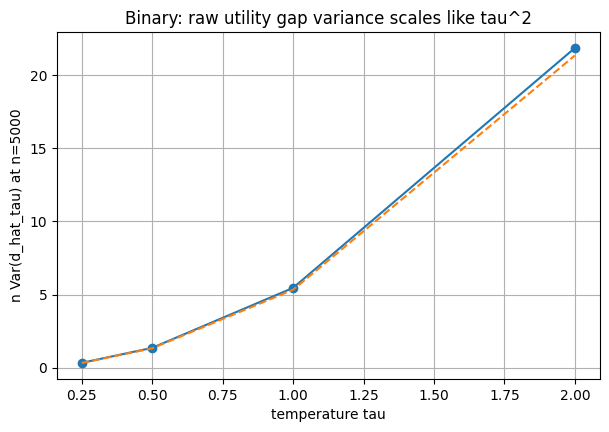

In [5]:

fig, ax = plt.subplots()
sub = binary_df[binary_df["n"] == max(n_grid)]
ax.plot(sub["tau"], sub["nVar_d_hat_tau"], marker="o")
ax.plot(
    sub["tau"],
    np.array(sub["tau"]) ** 2 * binary_floor,
    linestyle="--",
)
ax.set_title("Binary: raw utility gap variance scales like tau^2")
ax.set_xlabel("temperature tau")
ax.set_ylabel(f"n Var(d_hat_tau) at n={max(n_grid)}")
plt.show()



**Takeaway.**  
The normalized estimator \(\hat\theta = \hat d_\tau/\tau\) has a fixed multinomial / Bernoulli noise floor.  
Changing \(\tau\) only rescales the reported raw gap \(\hat d_\tau\).



## 2. Multiclass unrestricted softmax logits

Now we move to a genuinely multinomial shortfall model and estimate a full utility vector with a fixed temperature.

### DGP

Take several bounded scores \(s_i < 1\), define \(q(s)=1-s\), and generate winners from

\[
p_i^\star \propto (1-s_i)^{-\beta}.
\]

### Softmax fit

If we fit a full softmax utility vector \(u\) with a fixed temperature \(\tau\), then after choosing reference class \(0\),

\[
\theta_i = \frac{u_i-u_0}{\tau} = \log\frac{p_i}{p_0}, \qquad i=1,\dots,K-1.
\]

The plug-in estimator is

\[
\hat\theta_i = \log\frac{\hat p_i}{\hat p_0}.
\]

Its asymptotic covariance is

\[
\mathrm{Avar}\big(\sqrt{n}(\hat\theta-\theta^\star)\big)
= J \big(\mathrm{Diag}(p^\star)-p^\star p^{\star\top}\big) J^\top,
\]

which again depends on the multinomial probabilities but **not** on \(\tau\).


In [6]:

scores_multi = np.array([0.15, 0.45, 0.70, 0.90])
beta_multi = 0.8
p_multi = shortfall_probs(scores_multi, beta=beta_multi)
cov_theta_multi = multinomial_logit_cov(p_multi, ref=0)

theta_labels = [f"log(p_{j}/p_0)" for j in range(1, len(scores_multi))]
cov_df = pd.DataFrame(cov_theta_multi, index=theta_labels, columns=theta_labels)

print(f"scores = {scores_multi}")
print(f"beta = {beta_multi}")
print("true shortfall probabilities p* =")
display(pd.Series(p_multi, index=[f"cat_{j}" for j in range(len(scores_multi))]).to_frame("p_star"))

print("Theoretical asymptotic covariance of sqrt(n) * theta_hat:")
cov_df


scores = [0.15 0.45 0.7  0.9 ]
beta = 0.8
true shortfall probabilities p* =


,p_star
cat_0,0.0975
cat_1,0.1381
cat_2,0.2243
cat_3,0.5401


Theoretical asymptotic covariance of sqrt(n) * theta_hat:


,log(p_1/p_0),log(p_2/p_0),log(p_3/p_0)
log(p_1/p_0),17.4985,10.2575,10.2575
log(p_2/p_0),10.2575,14.7162,10.2575
log(p_3/p_0),10.2575,10.2575,12.1089


In [7]:

# Focus on the top-vs-reference contrast theta_top = log(p_3 / p_0)
top_idx = 3
theta_top_floor = cov_theta_multi[-1, -1]

multi_rows = []
R_multi = 12_000

for n in n_grid:
    counts = rng.multinomial(n, p_multi, size=R_multi)
    p_hat = smoothed_freq(counts, alpha=0.5)
    theta_hat = np.log(p_hat[:, 1:] / p_hat[:, [0]])
    theta_top_hat = theta_hat[:, -1]

    for tau in tau_grid:
        raw_gap_hat = tau * theta_top_hat
        multi_rows.append(
            {
                "n": n,
                "tau": tau,
                "nVar_theta_top_hat": n * np.var(theta_top_hat, ddof=1),
                "nVar_raw_gap_hat": n * np.var(raw_gap_hat, ddof=1),
            }
        )

multi_df = pd.DataFrame(multi_rows)
multi_df


,n,tau,nVar_theta_top_hat,nVar_raw_gap_hat
0,200,0.2500,12.2053,0.7628
1,200,0.5000,12.2053,3.0513
2,200,1.0000,12.2053,12.2053
3,200,2.0000,12.2053,48.8212
4,500,0.2500,12.2984,0.7687
5,500,0.5000,12.2984,3.0746
6,500,1.0000,12.2984,12.2984
7,500,2.0000,12.2984,49.1936
8,1000,0.2500,12.2698,0.7669
9,1000,0.5000,12.2698,3.0675


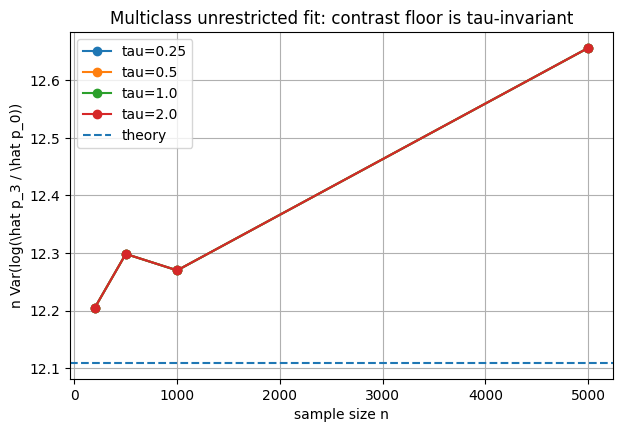

In [8]:

fig, ax = plt.subplots()
for tau in tau_grid:
    sub = multi_df[multi_df["tau"] == tau]
    ax.plot(sub["n"], sub["nVar_theta_top_hat"], marker="o", label=f"tau={tau}")
ax.axhline(theta_top_floor, linestyle="--", label="theory")
ax.set_title("Multiclass unrestricted fit: contrast floor is tau-invariant")
ax.set_xlabel("sample size n")
ax.set_ylabel(r"n Var(log(\hat p_3 / \hat p_0))")
ax.legend()
plt.show()


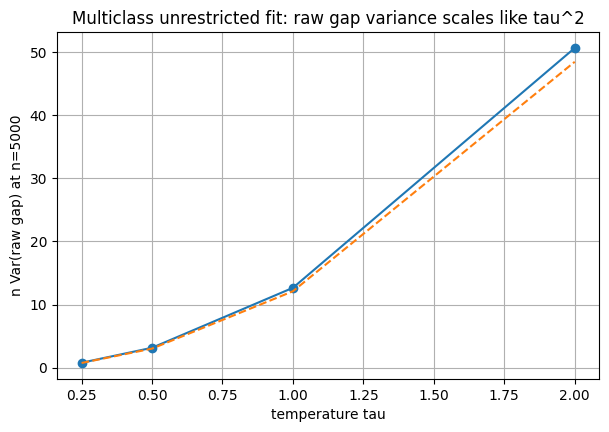

In [9]:

fig, ax = plt.subplots()
sub = multi_df[multi_df["n"] == max(n_grid)]
ax.plot(sub["tau"], sub["nVar_raw_gap_hat"], marker="o")
ax.plot(
    sub["tau"],
    np.array(sub["tau"]) ** 2 * theta_top_floor,
    linestyle="--",
)
ax.set_title("Multiclass unrestricted fit: raw gap variance scales like tau^2")
ax.set_xlabel("temperature tau")
ax.set_ylabel(f"n Var(raw gap) at n={max(n_grid)}")
plt.show()



**Takeaway.**  
Even when the softmax is given enough freedom to represent the full multinomial probability vector exactly, the estimated normalized logits inherit an irreducible multinomial noise floor. Temperature cannot remove it.



## 3. Misspecified one-parameter softmax fit

The previous section isolates pure sampling noise.  
This section adds a **link restriction** that is closer to the model-comparison discussion in the draft.

### True DGP

Keep the same shortfall probabilities

\[
p_i^\star \propto (1-s_i)^{-\beta}.
\]

### Fitted model

Now fit the **restricted** one-parameter softmax

\[
q_i(\theta) = \frac{\exp(\theta s_i)}{\sum_j \exp(\theta s_j)}.
\]

This is generally misspecified because the shortfall coordinate \( -\log(1-s)\) is not affine in the translation coordinate \(s\).

### Pseudo-true parameter and sandwich floor

For this one-parameter model, the pseudo-true \(\theta^\circ\) solves

\[
\mathbb E_{p^\star}[s] = \mathbb E_{q_{\theta^\circ}}[s].
\]

At \(\theta^\circ\),

\[
A = \mathrm{Var}_{q^\circ}(s), \qquad
B = \mathrm{Var}_{p^\star}(s),
\]

and the scalar Godambe floor is

\[
n\,\mathrm{Var}(\hat\theta) \to \frac{B}{A^2}.
\]

If we report the raw coefficient as \(\alpha_\tau = \tau \hat\theta\), then
\[
n\,\mathrm{Var}(\alpha_\tau) \to \tau^2 \frac{B}{A^2},
\]
while the identifiable quantity \(\hat\theta = \alpha_\tau/\tau\) keeps the same floor.


In [10]:

# Pseudo-true parameter under the restricted one-parameter softmax
mu_p = float(np.dot(p_multi, scores_multi))
theta_pseudo = invert_softmax_mean(np.array([mu_p]), scores_multi)[0]
q_pseudo = softmax_probs_from_theta(theta_pseudo, scores_multi)

mu_q = float(np.dot(q_pseudo, scores_multi))
A = float(np.dot(q_pseudo, (scores_multi - mu_q) ** 2))
B = float(np.dot(p_multi, (scores_multi - mu_q) ** 2))
godambe_floor = B / (A ** 2)

comparison = pd.DataFrame(
    {
        "score": scores_multi,
        "p_star_shortfall": p_multi,
        "q_pseudo_softmax": q_pseudo,
        "difference": p_multi - q_pseudo,
    }
)

print(f"Pseudo-true theta^o = {theta_pseudo:.6f}")
print(f"A = Var_q(s) = {A:.6f}")
print(f"B = Var_p*(s) = {B:.6f}")
print(f"Theoretical Godambe floor for n Var(theta_hat): {godambe_floor:.6f}")
comparison


Pseudo-true theta^o = 2.566055
A = Var_q(s) = 0.050023
B = Var_p*(s) = 0.059332
Theoretical Godambe floor for n Var(theta_hat): 23.710934


,score,p_star_shortfall,q_pseudo_softmax,difference
0,0.1500,0.0975,0.0709,0.0266
1,0.4500,0.1381,0.1530,-0.0149
2,0.7000,0.2243,0.2906,-0.0663
3,0.9000,0.5401,0.4855,0.0546


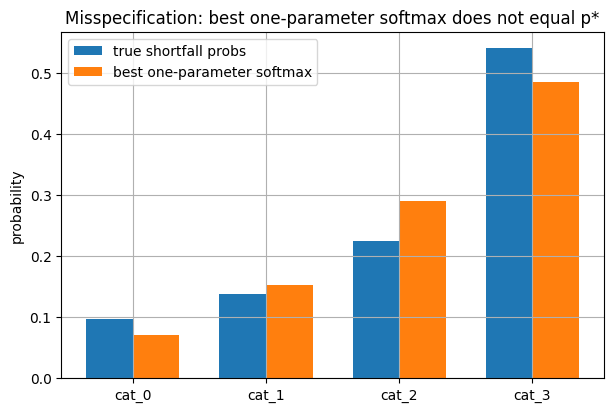

In [11]:

fig, ax = plt.subplots()
x = np.arange(len(scores_multi))
width = 0.35
ax.bar(x - width / 2, p_multi, width, label="true shortfall probs")
ax.bar(x + width / 2, q_pseudo, width, label="best one-parameter softmax")
ax.set_xticks(x)
ax.set_xticklabels([f"cat_{i}" for i in range(len(scores_multi))])
ax.set_title("Misspecification: best one-parameter softmax does not equal p*")
ax.set_ylabel("probability")
ax.legend()
plt.show()


In [12]:

qmle_rows = []
R_qmle = 10_000

for n in n_grid:
    counts = rng.multinomial(n, p_multi, size=R_qmle)
    sample_means = (counts / n) @ scores_multi
    theta_hat = invert_softmax_mean(sample_means, scores_multi)

    for tau in tau_grid:
        alpha_hat_tau = tau * theta_hat
        qmle_rows.append(
            {
                "n": n,
                "tau": tau,
                "nVar_theta_hat": n * np.var(theta_hat, ddof=1),
                "nVar_alpha_hat_tau": n * np.var(alpha_hat_tau, ddof=1),
            }
        )

qmle_df = pd.DataFrame(qmle_rows)
qmle_df


,n,tau,nVar_theta_hat,nVar_alpha_hat_tau
0,200,0.2500,24.3153,1.5197
1,200,0.5000,24.3153,6.0788
2,200,1.0000,24.3153,24.3153
3,200,2.0000,24.3153,97.2612
4,500,0.2500,24.2059,1.5129
5,500,0.5000,24.2059,6.0515
6,500,1.0000,24.2059,24.2059
7,500,2.0000,24.2059,96.8237
8,1000,0.2500,23.8668,1.4917
9,1000,0.5000,23.8668,5.9667


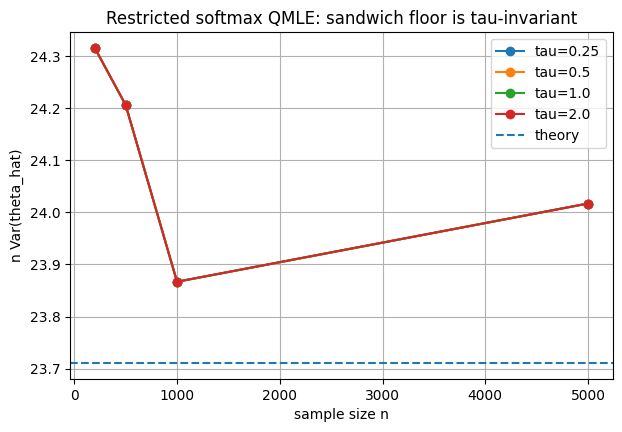

In [13]:

fig, ax = plt.subplots()
for tau in tau_grid:
    sub = qmle_df[qmle_df["tau"] == tau]
    ax.plot(sub["n"], sub["nVar_theta_hat"], marker="o", label=f"tau={tau}")
ax.axhline(godambe_floor, linestyle="--", label="theory")
ax.set_title("Restricted softmax QMLE: sandwich floor is tau-invariant")
ax.set_xlabel("sample size n")
ax.set_ylabel("n Var(theta_hat)")
ax.legend()
plt.show()


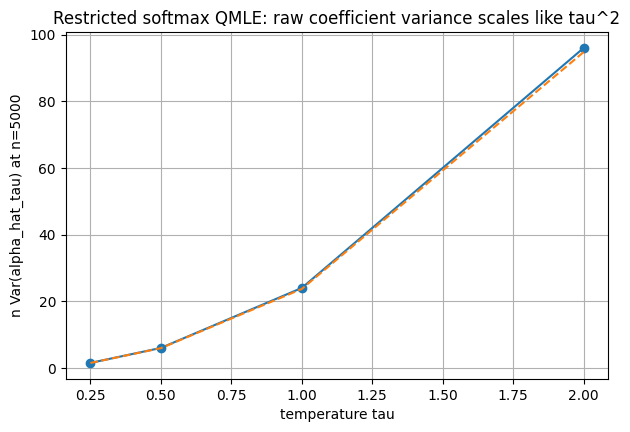

In [14]:

fig, ax = plt.subplots()
sub = qmle_df[qmle_df["n"] == max(n_grid)]
ax.plot(sub["tau"], sub["nVar_alpha_hat_tau"], marker="o")
ax.plot(
    sub["tau"],
    np.array(sub["tau"]) ** 2 * godambe_floor,
    linestyle="--",
)
ax.set_title("Restricted softmax QMLE: raw coefficient variance scales like tau^2")
ax.set_xlabel("temperature tau")
ax.set_ylabel(f"n Var(alpha_hat_tau) at n={max(n_grid)}")
plt.show()


## 4. Correctly specified Weibit removes the misspecification floor

The previous section showed that the restricted translation-coordinate softmax has an ordinary \(1/n\) sampling floor **around its pseudo-true parameter**.  
But for the paper we also want to show something stronger:

> if the data really come from the shortfall / Weibull law, then fitting the **correct** Weibit link removes the nonvanishing error floor for the **true** shortfall log-odds.

### Correct coordinate

For the endpoint-shortfall model with \(q(s)=1-s\), define the endpoint coordinate

\[
x_i = -\log(1-s_i).
\]

Then the true probabilities satisfy

\[
p_i^\star \propto (1-s_i)^{-\beta}
= \exp\{\beta x_i\},
\]

so the shortfall model is exactly a one-parameter multinomial logit in the coordinate \(x\):

\[
p_i^\star = \frac{\exp(\beta^\star x_i)}{\sum_j \exp(\beta^\star x_j)}.
\]

### Target functional

We compare both estimators on the same object: the true top-vs-reference log-odds

\[
\Lambda^\star
=
\log\frac{p^\star_{\mathrm{top}}}{p^\star_0}
=
\beta^\star(x_{\mathrm{top}}-x_0).
\]

* **Weibit MLE:** estimate \(\hat\beta_W\) using the correct coordinate \(x\), then report
  \[
  \hat\Lambda_W = \hat\beta_W(x_{\mathrm{top}}-x_0).
  \]
* **Misspecified softmax QMLE:** estimate \(\hat\theta_S\) using the translation coordinate \(s\), then report
  \[
  \hat\Lambda_S = \hat\theta_S(s_{\mathrm{top}}-s_0).
  \]

Because the Weibit model is correctly specified,

\[
n\,\mathrm{Var}(\hat\beta_W) \to I_W^{-1},
\qquad
I_W=\mathrm{Var}_{p^\star}(x),
\]

and therefore

\[
n\,\mathrm{MSE}(\hat\Lambda_W) \to \frac{(x_{\mathrm{top}}-x_0)^2}{I_W}.
\]

By contrast, the misspecified softmax estimator targets a pseudo-true translation log-odds
\[
\Lambda_S^\circ=\theta^\circ(s_{\mathrm{top}}-s_0),
\]
so its MSE for the true shortfall log-odds has the asymptotic form
\[
\mathrm{MSE}(\hat\Lambda_S)
=
(\Lambda_S^\circ-\Lambda^\star)^2 + O(n^{-1}).
\]

So the right comparison is:

* **Weibit:** only Fisher \(1/n\) noise remains.
* **Misspecified softmax:** a positive asymptotic bias floor remains.

In [15]:
# Correctly specified Weibit coordinates and theory
x_multi = -np.log1p(-scores_multi)
ref_idx = 0
top_idx = int(np.argmax(scores_multi))

x_gap = float(x_multi[top_idx] - x_multi[ref_idx])
s_gap = float(scores_multi[top_idx] - scores_multi[ref_idx])

lambda_true = beta_multi * x_gap

mu_x = float(np.dot(p_multi, x_multi))
beta_weibit_true = invert_softmax_mean(np.array([mu_x]), x_multi)[0]

I_w = float(np.dot(p_multi, (x_multi - mu_x) ** 2))
weibit_floor_beta = 1.0 / I_w
weibit_floor_lambda = (x_gap ** 2) / I_w

lambda_softmax_pseudo = theta_pseudo * s_gap
softmax_bias = lambda_softmax_pseudo - lambda_true
softmax_bias2 = softmax_bias ** 2
softmax_lambda_var_floor = (s_gap ** 2) * godambe_floor

comparison_summary = pd.Series(
    {
        "beta_true": beta_multi,
        "beta_weibit_recovered_from_true_p": beta_weibit_true,
        "theta_softmax_pseudo": theta_pseudo,
        "true_log_odds_top_vs_0": lambda_true,
        "softmax_pseudo_log_odds_top_vs_0": lambda_softmax_pseudo,
        "softmax_asymptotic_bias": softmax_bias,
        "softmax_bias_floor_MSE": softmax_bias2,
        "Weibit_theory_nVar_beta": weibit_floor_beta,
        "Weibit_theory_nMSE_true_log_odds": weibit_floor_lambda,
        "Softmax_theory_nVar_around_pseudo_log_odds": softmax_lambda_var_floor,
    }
)

comparison_summary.to_frame("value")

,value
beta_true,0.8000
beta_weibit_recovered_from_true_p,0.8000
theta_softmax_pseudo,2.5661
true_log_odds_top_vs_0,1.7121
softmax_pseudo_log_odds_top_vs_0,1.9245
softmax_asymptotic_bias,0.2125
softmax_bias_floor_MSE,0.0452
Weibit_theory_nVar_beta,1.5581
Weibit_theory_nMSE_true_log_odds,7.1360
Softmax_theory_nVar_around_pseudo_log_odds,13.3374


In [16]:
# Monte Carlo comparison on the true shortfall log-odds target
compare_rows = []
R_compare = 12_000
n_grid_compare = [100, 200, 500, 1_000, 2_000, 5_000, 10_000]

for n in n_grid_compare:
    counts = rng.multinomial(n, p_multi, size=R_compare)

    mean_s = (counts / n) @ scores_multi
    mean_x = (counts / n) @ x_multi

    theta_soft_hat = invert_softmax_mean(mean_s, scores_multi)
    beta_weibit_hat = invert_softmax_mean(mean_x, x_multi)

    lambda_soft_hat = theta_soft_hat * s_gap
    lambda_weibit_hat = beta_weibit_hat * x_gap

    compare_rows.append(
        {
            "n": n,
            "mean_beta_weibit_hat": np.mean(beta_weibit_hat),
            "nVar_beta_weibit_hat": n * np.var(beta_weibit_hat, ddof=1),
            "mean_lambda_weibit_hat": np.mean(lambda_weibit_hat),
            "mse_lambda_weibit": np.mean((lambda_weibit_hat - lambda_true) ** 2),
            "nMSE_lambda_weibit": n * np.mean((lambda_weibit_hat - lambda_true) ** 2),
            "mean_lambda_soft_hat": np.mean(lambda_soft_hat),
            "mse_lambda_softmax": np.mean((lambda_soft_hat - lambda_true) ** 2),
            "nMSE_lambda_softmax": n * np.mean((lambda_soft_hat - lambda_true) ** 2),
            "nMSE_lambda_softmax_around_pseudo": n * np.mean((lambda_soft_hat - lambda_softmax_pseudo) ** 2),
        }
    )

compare_df = pd.DataFrame(compare_rows)
compare_df

,n,mean_beta_weibit_hat,nVar_beta_weibit_hat,mean_lambda_weibit_hat,mse_lambda_weibit,nMSE_lambda_weibit,mean_lambda_soft_hat,mse_lambda_softmax,nMSE_lambda_softmax,nMSE_lambda_softmax_around_pseudo
0,100,0.8015,1.5792,1.7152,0.0723,7.2330,1.9447,0.1921,19.2075,13.8377
1,200,0.8007,1.5747,1.7135,0.0361,7.2118,1.9339,0.1170,23.4016,13.5758
2,500,0.8009,1.5728,1.7139,0.0144,7.2044,1.9301,0.0746,37.2814,13.5211
3,1000,0.8009,1.5730,1.7140,0.0072,7.2074,1.9285,0.0603,60.3065,13.4855
4,2000,0.7998,1.5567,1.7117,0.0036,7.1293,1.9244,0.0517,103.4511,13.2453
5,5000,0.8002,1.5692,1.7125,0.0014,7.1874,1.9254,0.0482,241.1630,13.5524
6,10000,0.8000,1.5463,1.7121,0.0007,7.0815,1.9247,0.0466,465.6024,13.3079


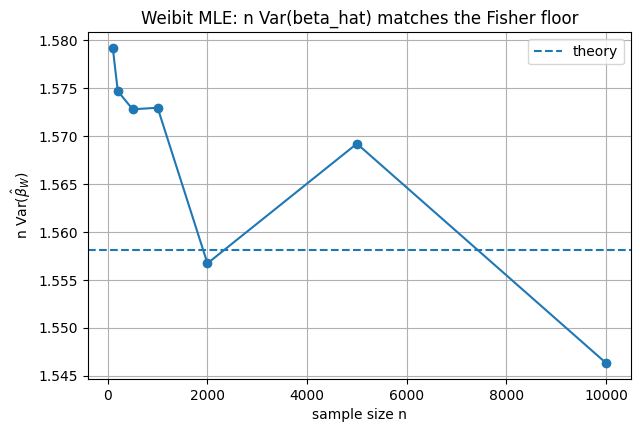

In [17]:
fig, ax = plt.subplots()
ax.plot(compare_df["n"], compare_df["nVar_beta_weibit_hat"], marker="o")
ax.axhline(weibit_floor_beta, linestyle="--", label="theory")
ax.set_title("Weibit MLE: n Var(beta_hat) matches the Fisher floor")
ax.set_xlabel("sample size n")
ax.set_ylabel(r"n Var($\hat\beta_W$)")
ax.legend()
plt.show()

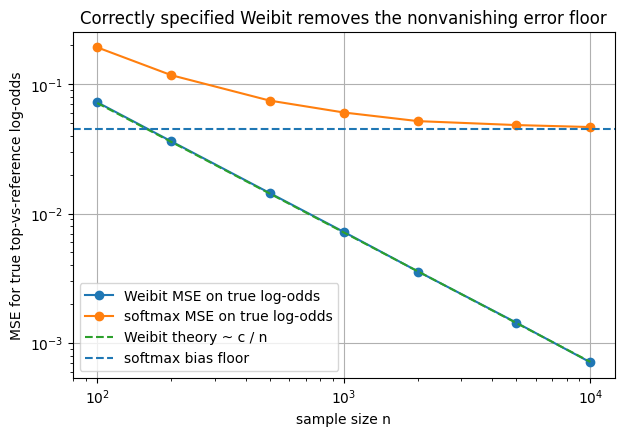

In [18]:
fig, ax = plt.subplots()
ax.plot(compare_df["n"], compare_df["mse_lambda_weibit"], marker="o", label="Weibit MSE on true log-odds")
ax.plot(compare_df["n"], compare_df["mse_lambda_softmax"], marker="o", label="softmax MSE on true log-odds")
ax.plot(
    compare_df["n"],
    weibit_floor_lambda / compare_df["n"],
    linestyle="--",
    label="Weibit theory ~ c / n",
)
ax.axhline(softmax_bias2, linestyle="--", label="softmax bias floor")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Correctly specified Weibit removes the nonvanishing error floor")
ax.set_xlabel("sample size n")
ax.set_ylabel("MSE for true top-vs-reference log-odds")
ax.legend()
plt.show()

**Takeaway.**  
The correctly specified Weibit link does **not** eliminate sampling noise; it still has the usual Fisher \(1/n\) variance.  
What it does eliminate is the **nonvanishing misspecification floor** of the translation-coordinate softmax when the target is the true shortfall log-odds.

## Final summary

Across all four experiments, the same hierarchy appears:

1. **Shortfall winner probabilities create ordinary multinomial sampling noise.**
2. **Softmax estimation must invert those noisy frequencies, so any identifiable normalized softmax quantity has a positive \(1/n\) variance floor.**
3. **Changing temperature only rescales raw utilities; it does not eliminate that normalized floor.**
4. **If the softmax link is also misspecified, there is an additional nonvanishing error floor for true shortfall log-odds.**
5. **Switching to the correctly specified Weibit link removes that misspecification floor and leaves only ordinary Fisher \(1/n\) noise.**

That is the statistical content that a purely local deterministic approximation argument misses.

## Possible extensions

Two easy next steps if you want to align this notebook even more closely with the draft:

* replace the toy score vector by a bank of random candidate sets and average the sandwich / Fisher matrices over those sets;
* simulate held-out log-likelihood and calibration error for softmax versus Weibit on random candidate sets, to mirror the empirical comparison in the paper.